Импорт библиотек

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE, ADASYN
import warnings
import os
import math

Загрузка датасетов, подготовка признаков и целевой переменной

In [57]:
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (10, 6)
plt.style.use('seaborn-v0_8-whitegrid')

train_path = r"C:\Users\Asus\Desktop\AI method\LB3\data\row\Data_Set_(A+B).csv"
test_path = r"C:\Users\Asus\Desktop\AI method\LB3\data\row\Data_Set_C.csv"

feature_cols = ['I1', 'I2', 'I3', 'gx', 'gy', 'gz', 'ax', 'ay', 'az', 
                'V1real', 'V2real', 'V3real', 'N1', 'N2', 'N3']

#экселевский формат отличается от csv, экспорт так же требует особого чтения
# Чтение с учётом русской локали Excel
# sep=';'  -> разделитель столбцов
# decimal=',' -> десятичный разделитель в числах
# encoding='cp1251' или 'utf-8-sig' -> кодировка кириллицы
try:
    df_train = pd.read_csv(train_path, sep=';', decimal=',', encoding='cp1251')
except Exception:
    # Фоллбэк на другие варианты, если первый не сработал
    try:
        df_train = pd.read_csv(train_path, sep=';', decimal=',', encoding='utf-8-sig')
    except Exception:
        df_train = pd.read_csv(train_path, sep=',', decimal='.', encoding='utf-8-sig')

print(f"Первые 3 строки:\n{df_train.head(3)}")
print(f"\nТипы данных:\n{df_train[feature_cols + ['Type']].dtypes}")
print("\n Информация о типах и пропусках:")
df_train.info()


y = (df_train['Type'] == 4).astype(int).values
X = df_train[feature_cols].values

print(f"Размерность: {X.shape}")
print(f"Классы:\n{pd.Series(y).value_counts()}")

Первые 3 строки:
         I1        I2        I3        gx        gy        gz        ax  \
0  1.126697  0.021116  0.927601  0.712941 -0.252941  1.081765  0.043529   
1  1.039215  0.015083  0.953243  0.229412  0.276471  0.485294  0.013672   
2  0.911011  0.004525  0.947210  1.170588  0.222941  0.664118  0.011704   

         ay        az      V1real    V2real      V3real    N1  N2    N3  Type  
0  0.003174  0.011661 -249.352941  4.764706  265.235294 -5070  30  5239     1  
1 -0.005572  0.012164 -260.470588  0.000000  263.647059 -5320  -9  5391     1  
2  0.003720  0.005744 -268.411765  0.000000  268.411765 -4829   6  4786     1  

Типы данных:
I1        float64
I2        float64
I3        float64
gx        float64
gy        float64
gz        float64
ax        float64
ay        float64
az        float64
V1real    float64
V2real    float64
V3real    float64
N1          int64
N2          int64
N3          int64
Type        int64
dtype: object

 Информация о типах и пропусках:
<class 'pand

Подбор на необработанных данных

In [58]:
# Быстрая проверка данных перед запуском
if np.isnan(X).any() or np.isinf(X).any():
    raise ValueError("В матрице признаков X найдены NaN или бесконечности. Проверьте очистку данных.")
if len(np.unique(y)) < 2:
    raise ValueError("Целевая переменная y содержит только один класс. Бинарная классификация невозможна.")
RANDOM_STATE = 42
print("Запуск предварительной кросс-валидации (cv=3)...")
print("-" * 60)
print("|Количесво слоёв| Функция|Solver  |Итер |   F1   |accuracy|")
print("|---------------|--------|--------|-----|--------|--------|")

best_cv_f1 = -1
best_params = None

for layers in [(32,), (64,), (128,), (64, 32), (86, 32), (86, 64), (128, 32)]:
    for act in ['relu', 'tanh']:
        for sol in ['adam', 'lbfgs']:
            for iters in [100, 150, 200, 500]:
                model = MLPClassifier(hidden_layer_sizes=layers, 
                                      activation=act, 
                                      solver=sol, 
                                      max_iter=iters, 
                                      random_state=RANDOM_STATE)
                try:
                    cv_f1 = cross_val_score(model, X, y, cv=3, scoring='f1').mean()
                    cv_acc = cross_val_score(model, X, y, cv=3, scoring='accuracy').mean()
                    print(f"{str(layers):15} | {act:6} | {sol:6} | {iters} | {cv_f1:.4f} | {cv_acc:.4f} |")
                    
                    if cv_f1 > best_cv_f1:
                        best_cv_f1 = cv_f1
                        best_params = {'hidden_layer_sizes': layers, 'activation': act, 'solver': sol, 'max_iter': iters}
                except Exception as e:
                    # Теперь ошибка будет видна в выводе
                    print(f"[SKIP] {layers}, {act}, {sol}, {iters} -> {e}")
                    continue

print("-" * 60)

if best_params is None:
    print("ВНИМАНИЕ: Все комбинации завершились с ошибкой. Применяется конфигурация по умолчанию.")
    best_params = {'hidden_layer_sizes': (64,), 'activation': 'relu', 'solver': 'adam', 'max_iter': 500}
    best_cv_f1 = 0.0
    
print(f"Лучшие параметры по CV_F1: {best_params}")
print(f"Значение CV_F1: {best_cv_f1:.4f}")

BEST_PARAMS = best_params.copy()

Запуск предварительной кросс-валидации (cv=3)...
------------------------------------------------------------
|Количесво слоёв| Функция|Solver  |Итер |   F1   |accuracy|
|---------------|--------|--------|-----|--------|--------|
(32,)           | relu   | adam   | 100 | 0.2200 | 0.5575 |
(32,)           | relu   | adam   | 150 | 0.2200 | 0.5575 |
(32,)           | relu   | adam   | 200 | 0.2200 | 0.5575 |
(32,)           | relu   | adam   | 500 | 0.2200 | 0.5575 |
(32,)           | relu   | lbfgs  | 100 | 0.2321 | 0.8065 |
(32,)           | relu   | lbfgs  | 150 | 0.2321 | 0.8065 |
(32,)           | relu   | lbfgs  | 200 | 0.2321 | 0.8065 |
(32,)           | relu   | lbfgs  | 500 | 0.2321 | 0.8065 |
(32,)           | tanh   | adam   | 100 | 0.1632 | 0.7729 |
(32,)           | tanh   | adam   | 150 | 0.1632 | 0.7729 |
(32,)           | tanh   | adam   | 200 | 0.1538 | 0.8125 |
(32,)           | tanh   | adam   | 500 | 0.1538 | 0.8125 |
(32,)           | tanh   | lbfgs  | 100 | 0.4508 |

Эксперимент на исходных данных

In [59]:
# Фиксируем параметры, найденные на этапе предварительного поиска
ANN_RAW = MLPClassifier(**BEST_PARAMS, random_state=RANDOM_STATE)

# Обучение и оценка
ANN_RAW.fit(X, y)
y_pred_raw = ANN_RAW.predict(X)

acc_raw = accuracy_score(y, y_pred_raw)
f1_raw = f1_score(y, y_pred_raw)
cv_raw = cross_val_score(ANN_RAW, X, y, cv=3, scoring='f1').mean()

print(f"Исходные данные | Accuracy: {acc_raw:.4f} | F1: {f1_raw:.4f} | CV_F1: {cv_raw:.4f}")
#print(f"Параметры сети: {BEST_PARAMS}")

Исходные данные | Accuracy: 0.9261 | F1: 0.8434 | CV_F1: 0.7915


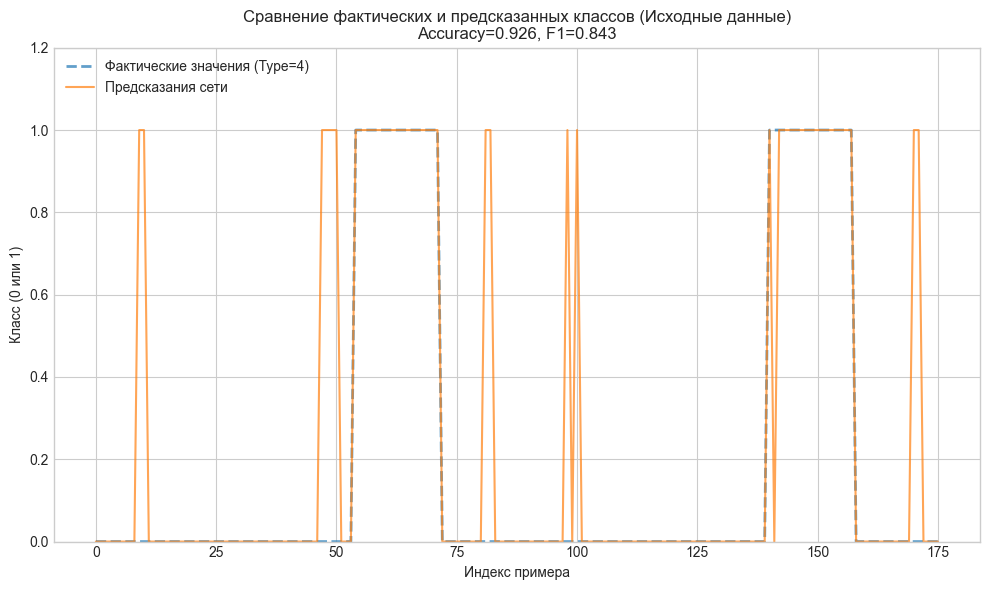

In [60]:
# График сравнения фактических и предсказанных значений
plt.figure(figsize=(10,6))
plt.plot(y, label='Фактические значения (Type=4)', linestyle='--', linewidth = 2.0, alpha=0.7)
plt.plot(y_pred_raw, label='Предсказания сети', alpha=0.7)
plt.xlabel('Индекс примера')
plt.ylabel('Класс (0 или 1)')
plt.ylim(0, 1.2)
plt.title(f'Сравнение фактических и предсказанных классов (Исходные данные)\nAccuracy={acc_raw:.3f}, F1={f1_raw:.3f}')
plt.legend(loc='upper left')
plt.tight_layout()
plt.savefig('reports/plot_raw.png', dpi=150, bbox_inches='tight')
plt.show()


Эксперемент по обучению на разбросанном наборе данных

Всего целевых строк: 36
Всего фоновых строк: 140
Количество групп целевых (по 2 строки): 18
Расчетный шаг (фоновых строк на группу): 7.78

Итоговая размерность: (176, 16)
Распределение классов:
Type
1    35
2    36
3    33
4    36
5    36
Name: count, dtype: int64


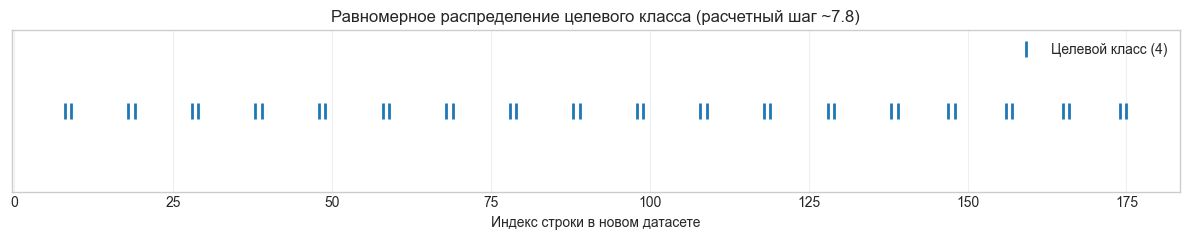

In [61]:
# 1. Разделение выборки на целевой и фоновый классы
df_target = df_train[df_train['Type'] == 4].copy()
df_other = df_train[df_train['Type'] != 4].copy()

n_target = len(df_target)
n_other = len(df_other)

# 2. Расчет параметров равномерного распределения
# Группируем целевые строки по 2
n_groups = math.ceil(n_target / 2)
# Рассчитываем шаг (количество фоновых строк между группами целевых)
step = n_other / n_groups

print(f"Всего целевых строк: {n_target}")
print(f"Всего фоновых строк: {n_other}")
print(f"Количество групп целевых (по 2 строки): {n_groups}")
print(f"Расчетный шаг (фоновых строк на группу): {step:.2f}")

# 3. Формирование нового датасета
new_df_parts = []
idx_other = 0
idx_target = 0

# Определяем базовый размер блока фоновых строк и количество блоков, 
# которые нужно увеличить на 1 для точного равномерного распределения
base_block = int(math.floor(step))
extra_count = n_other - (base_block * n_groups)

for i in range(n_groups):
    # Вставляем блок фоновых строк
    block_size = base_block + (1 if i < extra_count else 0)
    new_df_parts.append(df_other.iloc[idx_other:idx_other + block_size])
    idx_other += block_size
    
    # Вставляем группу из 2 целевых строк
    take_target = min(2, n_target - idx_target)
    new_df_parts.append(df_target.iloc[idx_target:idx_target + take_target])
    idx_target += take_target

# Добавляем оставшиеся фоновые строки, если они есть
if idx_other < n_other:
    new_df_parts.append(df_other.iloc[idx_other:])

# Сборка и сброс индексов
df_distributed = pd.concat(new_df_parts, ignore_index=True)

# 4. Валидация и визуализация
print(f"\nИтоговая размерность: {df_distributed.shape}")
print(f"Распределение классов:\n{df_distributed['Type'].value_counts().sort_index()}")

# График распределения целевых строк по новому датасету
target_indices = np.where(df_distributed['Type'] == 4)[0]
plt.figure(figsize=(12, 2.5))
plt.plot(target_indices, np.zeros_like(target_indices), '|', markersize=12, 
         markeredgewidth=2, label='Целевой класс (4)')
plt.yticks([])
plt.xlabel('Индекс строки в новом датасете')
plt.title(f'Равномерное распределение целевого класса (расчетный шаг ~{step:.1f})')
plt.legend(loc='upper right')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [62]:
X_distributed= df_distributed[feature_cols].values
y_distributed = (df_distributed['Type'] == 4).astype(int).values

ANN_DIST = MLPClassifier(**BEST_PARAMS, random_state=RANDOM_STATE)
ANN_DIST.fit(X_distributed, y_distributed)
y_pred_distributed = ANN_DIST.predict(X_distributed)

acc_distributed = accuracy_score(y_distributed, y_pred_distributed)
f1_distributed= f1_score(y_distributed, y_pred_distributed)
cv_distributed = cross_val_score(ANN_DIST, X_distributed, y_distributed, cv=3, scoring='f1').mean()

print(f"Исходные данные | Accuracy: {acc_raw:.4f} | F1: {f1_raw:.4f} | CV_F1: {cv_raw:.4f}")
print(f"Перемешанные данные | Accuracy: {acc_distributed:.4f} | F1: {f1_distributed:.4f} | CV_F1: {cv_distributed:.4f}")

Исходные данные | Accuracy: 0.9261 | F1: 0.8434 | CV_F1: 0.7915
Перемешанные данные | Accuracy: 0.8920 | F1: 0.7532 | CV_F1: 0.6005


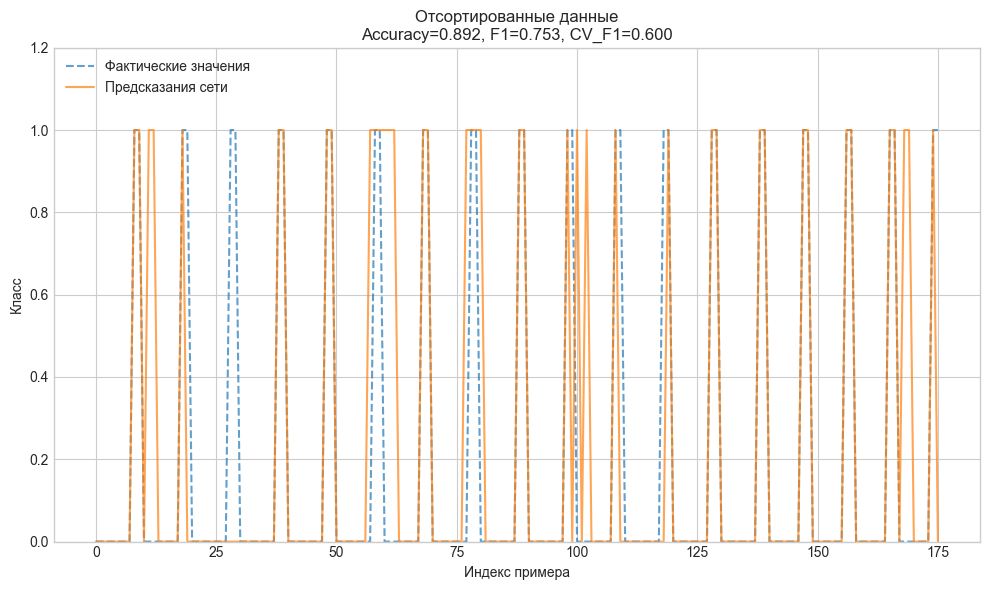

In [63]:
plt.figure()
plt.plot(y_distributed, label='Фактические значения', linestyle='--', alpha=0.7)
plt.plot(y_pred_distributed, label='Предсказания сети', alpha=0.7)
plt.xlabel('Индекс примера')
plt.ylabel('Класс')
plt.title(f'Отсортированные данные\nAccuracy={acc_distributed:.3f}, F1={f1_distributed:.3f}, CV_F1={cv_distributed:.3f}')
plt.ylim(0, 1.2)
plt.legend(loc='upper left')
plt.tight_layout()
plt.savefig('reports/plot_distributed.png', dpi=150, bbox_inches='tight')
plt.show()

Эксперимент на отсортированных данных

In [64]:
print("Применение сортировки...")
# Cортировка датасетов по целевому признаку
df_sorted = df_train.copy().sort_values(by='Type').reset_index(drop=True)
X_sorted = df_sorted[feature_cols].values
y_sorted = (df_sorted['Type'] == 4).astype(int).values

ANN_SORT = MLPClassifier(**BEST_PARAMS, random_state=RANDOM_STATE)
ANN_SORT.fit(X_sorted, y_sorted)
y_pred_sorted = ANN_SORT.predict(X_sorted)

acc_sort = accuracy_score(y_sorted, y_pred_sorted)
f1_sort = f1_score(y_sorted, y_pred_sorted)
cv_sort = cross_val_score(ANN_SORT, X_sorted, y_sorted, cv=3, scoring='f1').mean()

print(f"Исходные данные | Accuracy: {acc_raw:.4f} | F1: {f1_raw:.4f} | CV_F1: {cv_raw:.4f}")
print(f"Отсортированные данные | Accuracy: {acc_sort:.4f} | F1: {f1_sort:.4f} | CV_F1: {cv_sort:.4f}")

Применение сортировки...
Исходные данные | Accuracy: 0.9261 | F1: 0.8434 | CV_F1: 0.7915
Отсортированные данные | Accuracy: 0.9148 | F1: 0.7887 | CV_F1: 0.6926


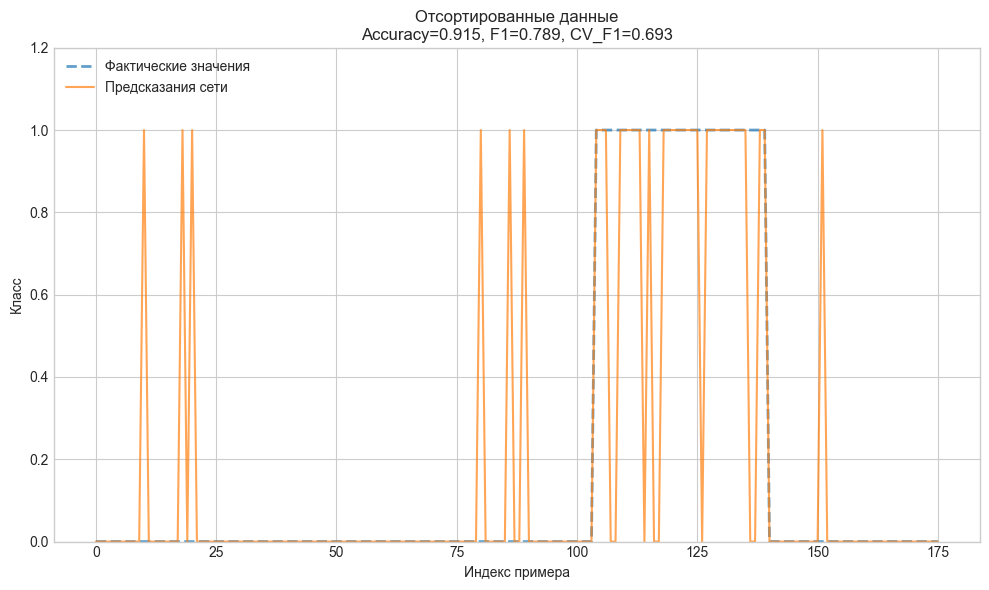

In [65]:
plt.figure()
plt.plot(y_sorted, label='Фактические значения', linestyle='--',linewidth = 2.0, alpha=0.7)
plt.plot(y_pred_sorted, label='Предсказания сети', alpha=0.7)
plt.xlabel('Индекс примера')
plt.ylabel('Класс')
plt.title(f'Отсортированные данные\nAccuracy={acc_sort:.3f}, F1={f1_sort:.3f}, CV_F1={cv_sort:.3f}')
plt.ylim(0, 1.2)
plt.legend(loc='upper left')
plt.tight_layout()
plt.savefig('reports/plot_sorted.png', dpi=150, bbox_inches='tight')
plt.show()

Эксперимент на нормализованных данных

In [66]:
use_sorted = f1_sort >= f1_raw
use_distributed = f1_distributed >= f1_raw
if  use_sorted:
    X_norm_base = X_sorted
    y_norm_base = y_sorted
elif use_distributed:
    X_norm_base = X_distributed
    y_norm_base = y_distributed
else:
    X_norm_base = X
    y_norm_base = y

scaler = MinMaxScaler()
X_norm = scaler.fit_transform(X_norm_base)

ANN_NORM = MLPClassifier(**BEST_PARAMS, random_state=42)
ANN_NORM.fit(X_norm, y_norm_base)
y_pred_norm = ANN_NORM.predict(X_norm)

acc_norm = accuracy_score(y_norm_base, y_pred_norm)
f1_norm = f1_score(y_norm_base, y_pred_norm)
cv_norm = cross_val_score(ANN_NORM, X_norm, y_norm_base, cv=3, scoring='f1').mean()


if use_sorted:
    print(f"Отсортированные данные | Accuracy: {acc_sort:.4f} | F1: {f1_sort:.4f} | CV_F1: {cv_sort:.4f}")
elif use_distributed:
    print(f"Перемешанные данные | Accuracy: {acc_distributed:.4f} | F1: {f1_distributed:.4f} | CV_F1: {cv_distributed:.4f}")
else:
    print(f"Исходные данные | Accuracy: {acc_raw:.4f} | F1: {f1_raw:.4f} | CV_F1: {cv_raw:.4f}")

print(f"Нормализованные данные | Accuracy: {acc_norm:.4f} | F1: {f1_norm:.4f} | CV_F1: {cv_norm:.4f}")

Исходные данные | Accuracy: 0.9261 | F1: 0.8434 | CV_F1: 0.7915
Нормализованные данные | Accuracy: 1.0000 | F1: 1.0000 | CV_F1: 0.9257


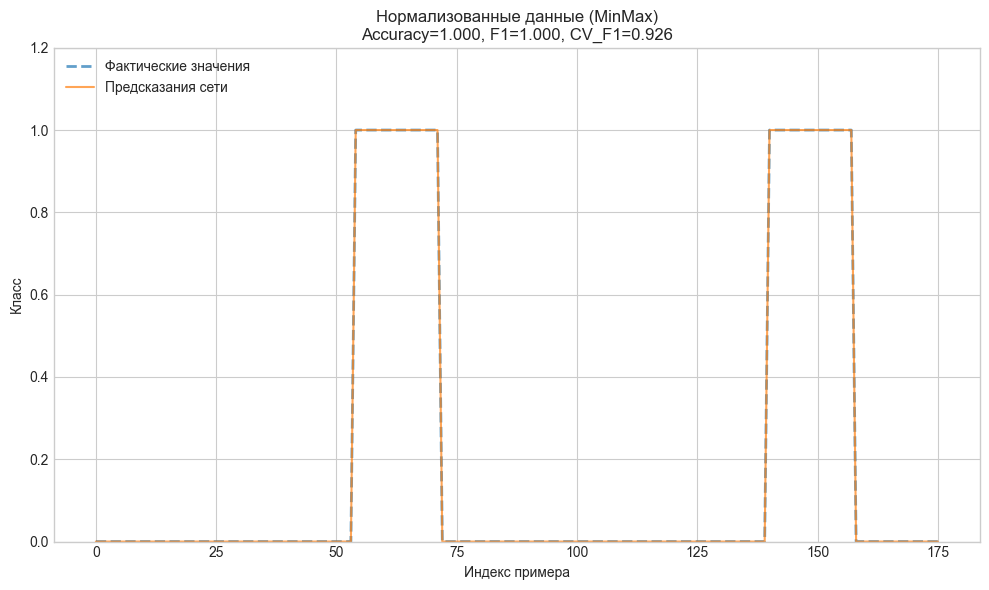

In [67]:
plt.figure()
plt.plot(y_norm_base, label='Фактические значения', linestyle='--',linewidth = 2.0, alpha=0.7)
plt.plot(y_pred_norm, label='Предсказания сети', alpha=0.7)
plt.xlabel('Индекс примера')
plt.ylabel('Класс')
plt.title(f'Нормализованные данные (MinMax)\nAccuracy={acc_norm:.3f}, F1={f1_norm:.3f}, CV_F1={cv_norm:.3f}')
plt.ylim(0, 1.2)
plt.legend(loc='upper left')
plt.tight_layout()
plt.savefig('reports/plot_normalized.png', dpi=150, bbox_inches='tight')
plt.show()


Эксперимент на сбалансированных данных

In [68]:
# Базовая выборка для балансировки - лучшая из предыдущих шагов. 
X_bal_base = X_norm.copy()
y_bal_base = y_norm_base.copy()

print("Применение SMOTE...")
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_bal_base, y_bal_base)

print("Применение ADASYN...")
adasyn = ADASYN(random_state=42)
X_adasyn, y_adasyn = adasyn.fit_resample(X_bal_base, y_bal_base)
# Берем нормализованную, так как SMOTE/ADASYN работают лучше на масштабируемых данных.

# Обучение на SMOTE
ANN_SMOTE = MLPClassifier(**BEST_PARAMS, random_state=42)
ANN_SMOTE.fit(X_smote, y_smote)
y_pred_smote = ANN_SMOTE.predict(X_smote)
f1_smote = f1_score(y_smote, y_pred_smote)
acc_smote = accuracy_score(y_smote, y_pred_smote)
cv_smote = cross_val_score(ANN_SMOTE, X_smote, y_smote, cv=3, scoring='f1').mean()
print(f"SMOTE  | Acc: {acc_smote:.4f} | F1: {f1_smote:.4f} | CV_F1: {cv_smote:.4f}")

# Обучение на ADASYN
ANN_ADASYN = MLPClassifier(**BEST_PARAMS, random_state=42)
ANN_ADASYN.fit(X_adasyn, y_adasyn)
y_pred_adasyn = ANN_ADASYN.predict(X_adasyn)
f1_adasyn = f1_score(y_adasyn, y_pred_adasyn)
acc_adasyn = accuracy_score(y_adasyn, y_pred_adasyn)
cv_adasyn = cross_val_score(ANN_ADASYN, X_adasyn, y_adasyn, cv=3, scoring='f1').mean()
print(f"ADASYN | Acc: {acc_adasyn:.4f} | F1: {f1_adasyn:.4f} | CV_F1: {cv_adasyn:.4f}")

# Выбираем лучший алгоритм балансировки
best_bal_method = 'SMOTE' if f1_smote >= f1_adasyn else 'ADASYN'
print(f"Лучший метод балансировки: {best_bal_method}")

X_best_bal = X_smote if best_bal_method == 'SMOTE' else X_adasyn
y_best_bal = y_smote if best_bal_method == 'SMOTE' else y_adasyn
y_pred_best_bal = y_pred_smote if best_bal_method == 'SMOTE' else y_pred_adasyn
f1_best_bal = f1_smote if best_bal_method == 'SMOTE' else f1_adasyn
acc_best_bal = acc_smote if best_bal_method == 'SMOTE' else acc_adasyn
cv_best_bal = cv_smote if best_bal_method == 'SMOTE' else cv_adasyn

Применение SMOTE...
Применение ADASYN...
SMOTE  | Acc: 1.0000 | F1: 1.0000 | CV_F1: 0.9894
ADASYN | Acc: 1.0000 | F1: 1.0000 | CV_F1: 0.9746
Лучший метод балансировки: SMOTE


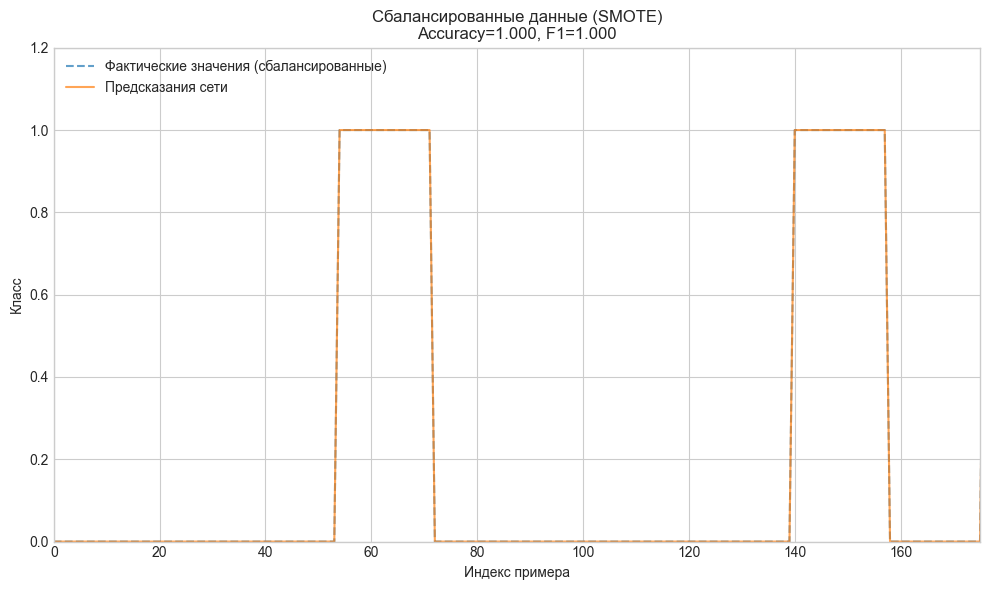

In [69]:
plt.figure()
plt.plot(y_best_bal, label='Фактические значения (сбалансированные)', linestyle='--', alpha=0.7)
plt.plot(y_pred_best_bal, label='Предсказания сети', alpha=0.7)
plt.xlabel('Индекс примера')
plt.ylabel('Класс')
plt.title(f'Сбалансированные данные ({best_bal_method})\nAccuracy={acc_best_bal:.3f}, F1={f1_best_bal:.3f}')
plt.ylim(0, 1.2)
plt.xlim(0, 175)
plt.legend(loc='upper left')
plt.tight_layout()
plt.savefig('reports/plot_balanced_SMOTE.png', dpi=300, bbox_inches='tight')
plt.show()


Проверка на контрольной выборке C

In [70]:
# Загрузка выборки C с теми же параметрами, что и обучающая
test_path = r"C:\Users\Asus\Desktop\AI method\LB3\data\row\Data_Set_C.csv"
try:
    df_test = pd.read_csv(test_path, sep=';', decimal=',', encoding='cp1251')
except Exception:
    df_test = pd.read_csv(test_path, sep=';', decimal=',', encoding='utf-8-sig')

# Приведение признаков к числовому типу
for col in feature_cols:
    df_test[col] = pd.to_numeric(df_test[col], errors='coerce')

# Очистка от бесконечностей и пропусков
df_test.replace([np.inf, -np.inf], np.nan, inplace=True)
df_test = df_test.dropna(subset=feature_cols + ['Type']).reset_index(drop=True)

y_test = (df_test['Type'] == 4).astype(int).values
X_test = df_test[feature_cols].values

# Применяем ту же предобработку, что и при обучении лучшей модели
X_test_norm = scaler.transform(X_test)

# Выбираем финальную модель для проверки
final_model = ANN_SMOTE

# Предсказание БЕЗ обучения (fit) на выборке C
y_pred_test = final_model.predict(X_test_norm)

acc_test = accuracy_score(y_test, y_pred_test)
f1_test = f1_score(y_test, y_pred_test)

print("=" * 60)
print("РЕЗУЛЬТАТ НА КОНТРОЛЬНОЙ ВЫБОРКЕ C")
print(f"Accuracy: {acc_test:.4f}")
print(f"F1-Score: {f1_test:.4f}")
print(f"Параметры сети: {BEST_PARAMS}")
print(f"Предобработка: Нормализация + {best_bal_method}")
print("=" * 60)

print(classification_report(y_test, y_pred_test, target_names=['Другой тип (0)', 'Тип 4 (1)']))

РЕЗУЛЬТАТ НА КОНТРОЛЬНОЙ ВЫБОРКЕ C
Accuracy: 0.9655
F1-Score: 0.9231
Параметры сети: {'hidden_layer_sizes': (64, 32), 'activation': 'tanh', 'solver': 'lbfgs', 'max_iter': 200}
Предобработка: Нормализация + SMOTE
                precision    recall  f1-score   support

Другой тип (0)       1.00      0.96      0.98        46
     Тип 4 (1)       0.86      1.00      0.92        12

      accuracy                           0.97        58
     macro avg       0.93      0.98      0.95        58
  weighted avg       0.97      0.97      0.97        58



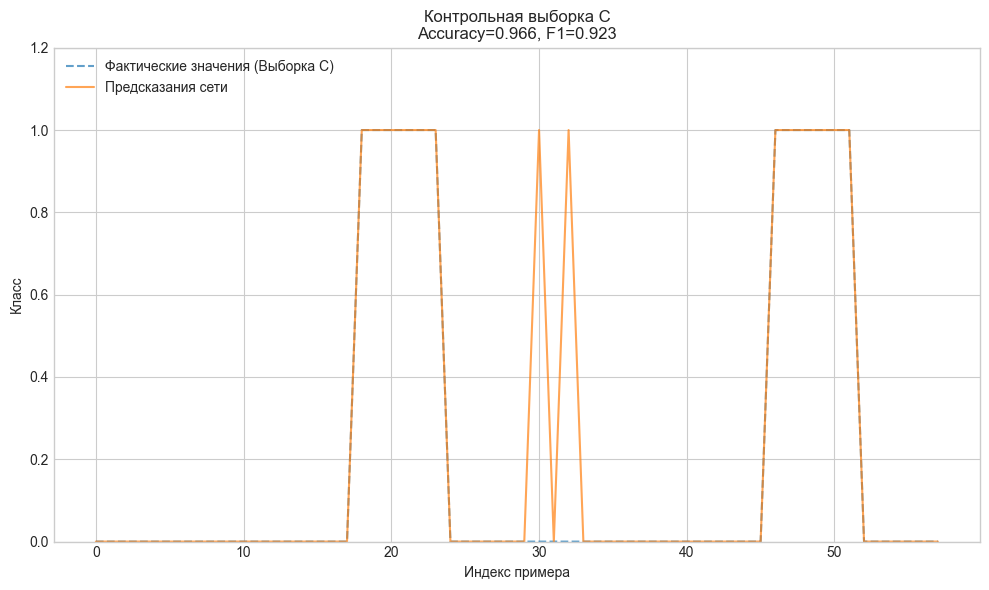

In [71]:
plt.figure()
plt.plot(y_test, label='Фактические значения (Выборка C)', linestyle='--', alpha=0.7)
plt.plot(y_pred_test, label='Предсказания сети', alpha=0.7)
plt.xlabel('Индекс примера')
plt.ylabel('Класс')
plt.title(f'Контрольная выборка C\nAccuracy={acc_test:.3f}, F1={f1_test:.3f}')
plt.ylim(0, 1.2)
plt.legend(loc='upper left')
plt.tight_layout()
plt.savefig('reports/plot_test_C.png', dpi=300, bbox_inches='tight')
plt.show()